In [1]:
# ========================
# IMPORTACIÓN DE PAQUETES
# ========================

# Numpy y Pandas: manipulación de datos numéricos y estructuras tabulares.
import numpy as np
import pandas as pd

# TensorFlow y TensorFlow Probability: base del modelo bayesiano en Meridian.
import tensorflow as tf
import tensorflow_probability as tfp

# ArviZ: análisis bayesiano y visualización de distribuciones a posteriori.
import arviz as az

# IPython: utilidades para entorno interactivo (no se usa aún, pero útil para display).
import IPython

# ===============================
# MÓDULOS DE MERIDIAN (OFICIALES)
# ===============================

# Constantes internas de Meridian.
from meridian import constants

# Módulos de carga y preparación de datos.
from meridian.data import load

# Módulos de modelado y especificación del modelo.
from meridian.model import model
from meridian.model import spec
from meridian.model import prior_distribution
from meridian.model.model import Meridian  # clase principal del modelo

# Módulos de análisis del modelo entrenado.
from meridian.analysis import optimizer     # optimización de presupuesto
from meridian.analysis import visualizer    # gráficos y visualizaciones
from meridian.analysis import summarizer    # resumen HTML del modelo

# =============================
# UTILIDADES ADICIONALES
# =============================

# tqdm: barra de progreso útil en loops largos o procesos MCMC.
from tqdm import tqdm

# ============================
# VERIFICACIÓN DEL ENTORNO
# ============================

# Verificar si hay GPU disponible y cuánta RAM tiene el entorno.
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9

print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
print("Num CPUs Available: ", len(tf.config.experimental.list_physical_devices('CPU')))

Your runtime has 17.2 gigabytes of available RAM

Num GPUs Available:  0
Num CPUs Available:  1


In [2]:
# =====================================
# CARGAR Y FORMATEAR LOS DATOS ORIGINALES
# =====================================

# Ruta al archivo CSV con todos los datos consolidados.
file_path = 'input_meridian.csv'

# Cargar los datos en un DataFrame.
df = pd.read_csv(file_path)

# =====================================
# CONVERSIÓN DE LA COLUMNA DE FECHA
# =====================================

# Convertir la columna 'fecha' al tipo datetime de Pandas.
# Esto es necesario porque Meridian requiere que la dimensión temporal esté en formato datetime.
df['fecha'] = pd.to_datetime(df['fecha'])

# Mostrar el dataframe
df.head()

,fecha,medios-inv-tv,medios-inv-radio,medios-inv-prensa,medios-inv-revistas,medios-inv-exterior,medios-inv-sem,medios-inv-rtb,medios-inv-afiliacion,medios-inv-rrss,...,medios-inv-patrocinio,control-not-set_consideracion-bankinter,control-not-set_consideracion-caixa,control-not-set_consideracion-ing,control-not-set_consideracion-sabadell,control-not-set_consideracion-ibercaja,medios-inv-digital-performance,medios-inv-digital-branding,medios-inv-off,medios-inv-news-radio
0,2025-11-01,3557.40000,6315.0626,0.0000,0.0,2159.8500,34743.189800,2451.85930,11328.625,0.000000,...,201083.00,0.200667,0.414556,0.389778,0.236889,0.208111,75389.062100,4235.000000,5717.25000,6315.0626
1,2025-10-01,16388.24000,19184.6952,14763.5125,0.0,1727.8800,37308.125942,15863.95871,0.000,13730.767742,...,228943.00,0.197333,0.439778,0.418556,0.198889,0.231778,142277.673786,63168.686226,18116.12000,33948.2077
2,2025-09-01,17902.35656,21380.5185,32491.5250,0.0,2591.8200,27300.874260,0.00000,0.000,0.000000,...,257733.06,0.153667,0.459778,0.386000,0.205222,0.214222,54846.216012,2662.000000,20494.17656,53872.0435
3,2025-08-01,2299.00000,0.0000,0.0000,0.0,1727.8800,25539.866880,0.00000,0.000,0.000000,...,210130.00,0.188556,0.428444,0.381222,0.240111,0.206222,25539.866880,0.000000,4026.88000,0.0000
4,2025-07-01,786.50000,0.0000,10587.5000,0.0,2051.8575,24797.057560,0.00000,0.000,0.000000,...,83000.00,0.166556,0.432778,0.378889,0.225000,0.215111,26299.877560,1331.000000,2838.35750,10587.5000


In [3]:
# =======================================
# DEFINIR LAS COLUMNAS CLAVE DEL MODELO
# =======================================

# COLUMNAS DE FOURIER
df = df.sort_values('fecha').copy()

# Índice temporal en meses desde el inicio
df['t_months'] = (df['fecha'].dt.year - df['fecha'].dt.year.min())*12 + (df['fecha'].dt.month - df['fecha'].dt.month.min())
df['t_months'] = df['t_months'].astype(float)

PERIOD_MONTHLY = 12.0   # ciclo anual en meses
K = 4                   # prueba K=1,2,3 y elige por validación

fourier_cols = []
for k in range(1, K+1):
    df[f'sin{k}_m'] = np.sin(2*np.pi*k*df['t_months']/PERIOD_MONTHLY)
    df[f'cos{k}_m'] = np.cos(2*np.pi*k*df['t_months']/PERIOD_MONTHLY)
    fourier_cols += [f'sin{k}_m', f'cos{k}_m']

# TRANSFORMACIÓN DEL KPI
kpi_column = 'control-not-set_consideracion-ibercaja'
kpi_column_transformed = 'set_consideracion_transformed'
df[kpi_column_transformed] = df[kpi_column] * 100

# Lista de columnas del DataFrame que contienen el gasto por canal de medios pagados.
media_spend = ["medios-inv-digital-performance",
    "medios-inv-digital-branding",
    "medios-inv-off",
    "medios-inv-patrocinio",
    "medios-inv-news-radio"
    ]

# En este ejemplo, usamos directamente las columnas de inversión como proxy de exposición (sin datos de alcance).
# Esto es válido según la documentación si no se cuenta con datos de reach/frequency.
# Divide por 1000 (convierte € a miles de €)
for col in media_spend:
  df[col] = df[col] / 1000
media = media_spend

# Crear un diccionario que mapea cada columna de inversión al nombre del canal sin el prefijo "inv_".
# Este diccionario se usa para estandarizar nombres internos en Meridian.
media_spend_to_channel = {col: col.replace("inv-", "") for col in media_spend}
media_to_channel = media_spend_to_channel.copy()  # En este caso, coinciden porque usamos inversión como exposición.

In [4]:
# ======================================
# MAPEO DE COLUMNAS PARA EL LOADER
# ======================================

# Crear un objeto `CoordToColumns` que indica qué columnas del DataFrame corresponden a:
# - La dimensión temporal.
# - La dimensión geográfica.
# - El KPI objetivo (en este caso: ingresos ajustados).
# - Variables de control (factores externos que influyen en el KPI pero no son marketing).
# - Medios pagados (en este caso, usando inversión como exposición).
# - Medios orgánicos (ej: envíos de emails, tráfico directo, etc.).
coord_to_columns = load.CoordToColumns(
    time='fecha',                                 # (str) Columna temporal.
    #geo='geo',                                   # (str) Columna geográfica.
    kpi=kpi_column_transformed,                   # (str) KPI a modelar.
    controls=fourier_cols,                        # (list[str]) Variables de control opcionales.
    media=media,                                  # (list[str]) Columnas de exposición de medios.
    media_spend=media,                            # (list[str]) Columnas de gasto de medios.
    organic_media=['org-email', 'org-carta', 'org-sms', 'org-push'],                      # (list[str]) Medios orgánicos, si existen.
    reach=None,                                    # (list[str]) Columnas de alcance (opcional, no usado aquí).
    frequency=None,                                # (list[str]) Columnas de frecuencia (opcional).
    rf_spend=None,                                 # (list[str]) Gasto asociado a reach/frequency (opcional).
    non_media_treatments=None,                     # (list[str]) Intervenciones no mediáticas (opcional).
    revenue_per_kpi=None                           # (str) Valor monetario por conversión (opcional, si kpi no es revenue directo).
)


# ===========================================
# CARGA DE DATOS CON DataFrameDataLoader
# ===========================================

# Crear el loader que toma un DataFrame en formato ancho (wide) y lo transforma a los tensores que espera Meridian.
loader = load.DataFrameDataLoader(
    df=df,                                         # (pandas.DataFrame) Tu dataset.
    kpi_type='non_revenue',                            # (str) 'revenue' o 'conversion'.
    coord_to_columns=coord_to_columns,             # (CoordToColumns) El mapeo creado arriba.
    media_to_channel=media_to_channel,             # (dict) Mapeo de medios pagados.
    media_spend_to_channel=media_spend_to_channel, # (dict) Mapeo de gasto en medios pagados.
)

# Cargar los datos procesados. Esto generará las estructuras internas necesarias para el modelo.
loaded_data = loader.load()
loaded_data.as_dataset()

/Users/mauriciosierra/Documents/meridian-mio/meridian/data/input_data.py:524: UserWarning: Consider setting custom priors, as kpi_type was specified as `non_revenue` with no `revenue_per_kpi` being set. Otherwise, the total media contribution prior will be used with `p_mean=0.4` and `p_sd=0.2`. Further documentation available at https://developers.google.com/meridian/docs/advanced-modeling/unknown-revenue-kpi-custom#set-total-paid-media-contribution-prior
  warnings.warn(


<xarray.Dataset> Size: 19kB
Dimensions:                (time: 47, geo: 1, control_variable: 8,
                            media_channel: 5, media_time: 47,
                            organic_media_channel: 4)
Coordinates:
  * time                   (time) <U28 5kB '2022-01-01' ... '2025-11-01'
  * geo                    (geo) <U12 48B 'national_geo'
  * control_variable       (control_variable) object 64B 'sin1_m' ... 'cos4_m'
  * media_channel          (media_channel) object 40B 'medios-digital-perform...
  * media_time             (media_time) <U28 5kB '2022-01-01' ... '2025-11-01'
  * organic_media_channel  (organic_media_channel) object 32B 'org-email' ......
Data variables:
    kpi                    (geo, time) float64 376B 26.0 26.0 ... 23.18 20.81
    population             (geo) float64 8B 1.0
    controls               (geo, time, control_variable) float64 3kB 0.0 ... ...
    media                  (geo, media_time, media_channel) float64 2kB 38.41...
    media_spend            (geo, time, media_channel) float64 2kB 38.41 ... 6...
    organic_media          (geo, media_time, organic_media_channel) int64 2kB ...

In [5]:
# =======================================
# DEFINIR LA DISTRIBUCIÓN A PRIORI DEL ROI
# =======================================

# Se define una distribución Log-Normal como distribución a priori para el ROI (Retorno de Inversión)
# Esta elección es compatible con la reparametrización de Meridian basada en ROI.
# LogNormal asegura que el ROI sea siempre positivo.

# Crear una única distribución LogNormal vectorizada para todos los canales
# roi_m_prior = tfp.distributions.LogNormal(
#     loc=[1.2, 1.2, 0.6, 1.2, 1.2],    # loc individual para cada canal (mu)
#     scale=[0.5, 0.5, 0.5, 0.5, 0.5],  # scale individual para cada canal (sigma)
#     name="roi_m"
# )

# Definir el prior completo con TODOS los parámetros personalizables
prior = prior_distribution.PriorDistribution(
    roi_m=tfp.distributions.HalfNormal(10.0),  # ROI para medios pagados (vectorizado)
    roi_rf=tfp.distributions.LogNormal(loc=1.6, scale=0.4, name=constants.ROI_RF),  # ROI para medios con Reach/Frequency
    mroi_m=tfp.distributions.LogNormal(loc=1.6, scale=0.4, name=constants.MROI_M),  # ROI marginal para medios pagados
    mroi_rf=tfp.distributions.LogNormal(loc=1.6, scale=0.4, name=constants.MROI_RF),  # ROI marginal para medios con Reach/Frequency

    eta_m=tfp.distributions.HalfNormal(5.0),    # Regularización entre geos para medios pagados
    eta_rf=tfp.distributions.HalfNormal(5.0),   # Regularización entre geos para medios con Reach/Frequency
    eta_om=tfp.distributions.HalfNormal(5.0),   # Regularización entre geos para medios orgánicos
    eta_orf=tfp.distributions.HalfNormal(5.0),  # Regularización entre geos para medios orgánicos con Reach/Frequency

    xi_c=tfp.distributions.HalfNormal(5.0),     # Regularización entre geos para controles (lluvia)
    xi_n=tfp.distributions.HalfNormal(5.0),     # Regularización entre geos para tratamientos no mediáticos (descuentos)

    beta_m=tfp.distributions.HalfNormal(5.0),   # Prior para betas de medios pagados (no se usa en este ejemplo porque tenemos paid_media_prior_type='roi' en el model_spec)
    beta_rf=tfp.distributions.HalfNormal(5.0),  # Prior para betas de medios con Reach/Frequency (no se usa en este ejemplo porque tenemos paid_media_prior_type='roi' en el model_spec)
    beta_om=tfp.distributions.HalfNormal(0.3),  # Prior para betas de medios orgánicos
    beta_orf=tfp.distributions.HalfNormal(5.0), # Prior para betas de medios orgánicos con Reach/Frequency

    gamma_c=tfp.distributions.Normal(0.0, 5.0),  # Prior para controles (lluvia)
    gamma_n=tfp.distributions.Normal(0.0, 5.0),  # Prior para tratamientos no mediáticos (descuentos)

    sigma=tfp.distributions.HalfNormal(5.0),     # Prior para el ruido residual (error)

    # Priors para el efecto de Adstock (permite ajustar la tasa de decaimiento)
    alpha_m=tfp.distributions.Uniform(0.0, 1.0),     # Medios pagados
    alpha_om=tfp.distributions.Uniform(0.0, 1.0),    # Medios orgánicos
    alpha_rf=tfp.distributions.Uniform(0.0, 1.0),    # Medios pagados con datos de alcance y frecuencia
    alpha_orf=tfp.distributions.Uniform(0.0, 1.0)    # Medios orgánicos con datos de alcance y frecuencia
)

adstock_decay_spec = {
    "medios-digital-performance": "binomial",
    "medios-digital-branding": "binomial",
    "medios-patrocinio": "geometric",
    "medios-news-radio": "binomial",
    "medios-off": "binomial"
}

holdout_ids = np.random.choice([True, False], size=len(df), p=[0.2, 0.8])
holdout_ids = np.array(holdout_ids, dtype=bool)

# ============================================
# CONFIGURACIÓN DE LA ESPECIFICACIÓN DEL MODELO
# ============================================

# Se define un objeto ModelSpec con los hiperparámetros y opciones de estructura.

model_spec = spec.ModelSpec(
    prior=prior,                                 # Prior definido arriba
    media_effects_dist='log_normal',             # 'log_normal' (default) o 'normal'
    adstock_decay_spec = adstock_decay_spec,
    hill_before_adstock=False,                   # Primero aplica adstock y luego Hill
    max_lag=8,                                   # Máximo lag (rezago) en semanas
    unique_sigma_for_each_geo=True,              # (solo para modelos geo-level). Error residual individual para cada geo o compartido (True/False)
    paid_media_prior_type='roi',                # Reparametrización en función de ROI ('roi', 'mroi' o 'coefficient')
    roi_calibration_period=None,                 # Período para calibrar ROIs si se usa calibración. Para EXPERIMENTOS INCREMENTALES la pasamos la matriz roi_calibration_period
    rf_roi_calibration_period=None,              # Idem para Reach/Frequency
    #knots=20,                                   # Número de nudos para baseline temporal (None usa default = 1 para modelos nacionales y 'n_times' para modelos geo). Ej: [1, 13, 26, 39, 52] uno en cada trimestre
    enable_aks=True,
    baseline_geo=None,                           # Geo de referencia para baseline en modelos geográficos ('España')
    holdout_id=holdout_ids,                             # Holdout ID si se usa validación fuera de muestra. Un array booleano holdout_id con valores [true, false]
    control_population_scaling_id=None           # Scaling ID para población de control. controls=['impresiones_competencia', 'lluvia']. control_population_scaling_id = [True, False]
)


# ============================
# CREAR Y ENTRENAR EL MODELO
# ============================

# Crear una instancia del modelo con los datos cargados y la configuración definida.
mmm = Meridian(
    input_data=loaded_data,
    model_spec=model_spec
)


# ======================================
# MUESTREO DESDE LA DISTRIBUCIÓN A PRIORI
# ======================================

# Genera 500 muestras de los parámetros del modelo usando solo las distribuciones a priori (sin usar los datos aún).
# Sirve para visualizar el conocimiento previo sobre los parámetros.
mmm.sample_prior(n_draws=500)


# =========================================
# ENTRENAMIENTO DEL MODELO CON MCMC POSTERIOR
# =========================================

# Inicia el muestreo MCMC usando el algoritmo NUTS (No-U-Turn Sampler).
# Esto estima la distribución a posteriori de todos los parámetros, dado los datos observados.
N_ITERATIONS = 2000
N_CHAINS = 3
with tqdm(total=N_CHAINS * N_ITERATIONS, desc="Progreso del entrenamiento") as pbar:
    mmm.sample_posterior(
        n_chains=N_CHAINS,        # Número de cadenas paralelas (ayuda a verificar convergencia).
        n_adapt=N_ITERATIONS,     # Número de pasos de calentamiento por cadena (subir a 1000 o 2000 si los R-hat son altos o no hay convergencia)
        n_burnin=0,               # Iteraciones iniciales a descartar por cada cadena (puede estar entre 0 y 100 y solo subirlo si vemos en los gráficos trace plots que tarda en estabilizarse)
        n_keep=N_ITERATIONS,      # Iteraciones por cadena que se conservarán para inferencia. Subir a 2000 si los intervalos de credibilidad son muy anchos o los gráficos de densidad "ruidosos"
    )
    pbar.update(N_CHAINS * N_ITERATIONS)  # Actualiza barra de progreso (visual).

/Users/mauriciosierra/Documents/meridian-mio/meridian/model/spec.py:262: UserWarning: Using `paid_media_prior_type` parameter will set prior types for media and RF at the same time. This is deprecated and will be removed in a future version of Meridian. Use `media_prior_type` and `rf_prior_type` instead.
  warnings.warn(
/Users/mauriciosierra/Documents/meridian-mio/meridian/model/model.py:65: UserWarning: In a nationally aggregated model, the `media_effects_dist` will be reset to `normal`.
  warnings.warn(
/Users/mauriciosierra/Documents/meridian-mio/meridian/model/model.py:65: UserWarning: In a nationally aggregated model, the `unique_sigma_for_each_geo` will be reset to `False`.
  warnings.warn(
/Users/mauriciosierra/Documents/meridian-mio/meridian/model/model.py:880: UserWarning: Custom prior(s) `beta_m, mroi_m` are ignored when `media_prior_type` is set to "roi".
  warnings.warn(
/Users/mauriciosierra/Documents/meridian-mio/meridian/model/model.py:880: UserWarning: Custom prior(s) 

In [6]:
# ===================================
# MÉTRICAS DE PRECISIÓN DEL MODELO
# ===================================

# Crear un objeto de diagnóstico
model_diagnostics = visualizer.ModelDiagnostics(mmm)

# 📋 Tabla de precisión predictiva (R², MAPE, WMAPE)
predictive_accuracy = model_diagnostics.predictive_accuracy_table()

print("📊 Métricas de Precisión del Modelo (R², MAPE, WMAPE):")
display(predictive_accuracy)

/Users/mauriciosierra/Documents/meridian-mio/meridian/analysis/analyzer.py:945: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
/Users/mauriciosierra/Documents/meridian-mio/meridian/analysis/analyzer.py:630: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(


📊 Métricas de Precisión del Modelo (R², MAPE, WMAPE):


,metric,geo_granularity,evaluation_set,value
0,R_Squared,national,Train,0.865040
1,R_Squared,national,Test,0.400901
2,R_Squared,national,All Data,0.771186
3,MAPE,national,Train,0.024458
4,MAPE,national,Test,0.045560
5,MAPE,national,All Data,0.028050
6,wMAPE,national,Train,0.024234
7,wMAPE,national,Test,0.047946
8,wMAPE,national,All Data,0.028325


/Users/mauriciosierra/Documents/meridian-mio/meridian/analysis/analyzer.py:945: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(


alt.LayerChart(...)

alt.FacetChart(...)

/Users/mauriciosierra/Documents/meridian-mio/meridian/analysis/analyzer.py:945: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(


alt.FacetChart(...)

alt.FacetChart(...)

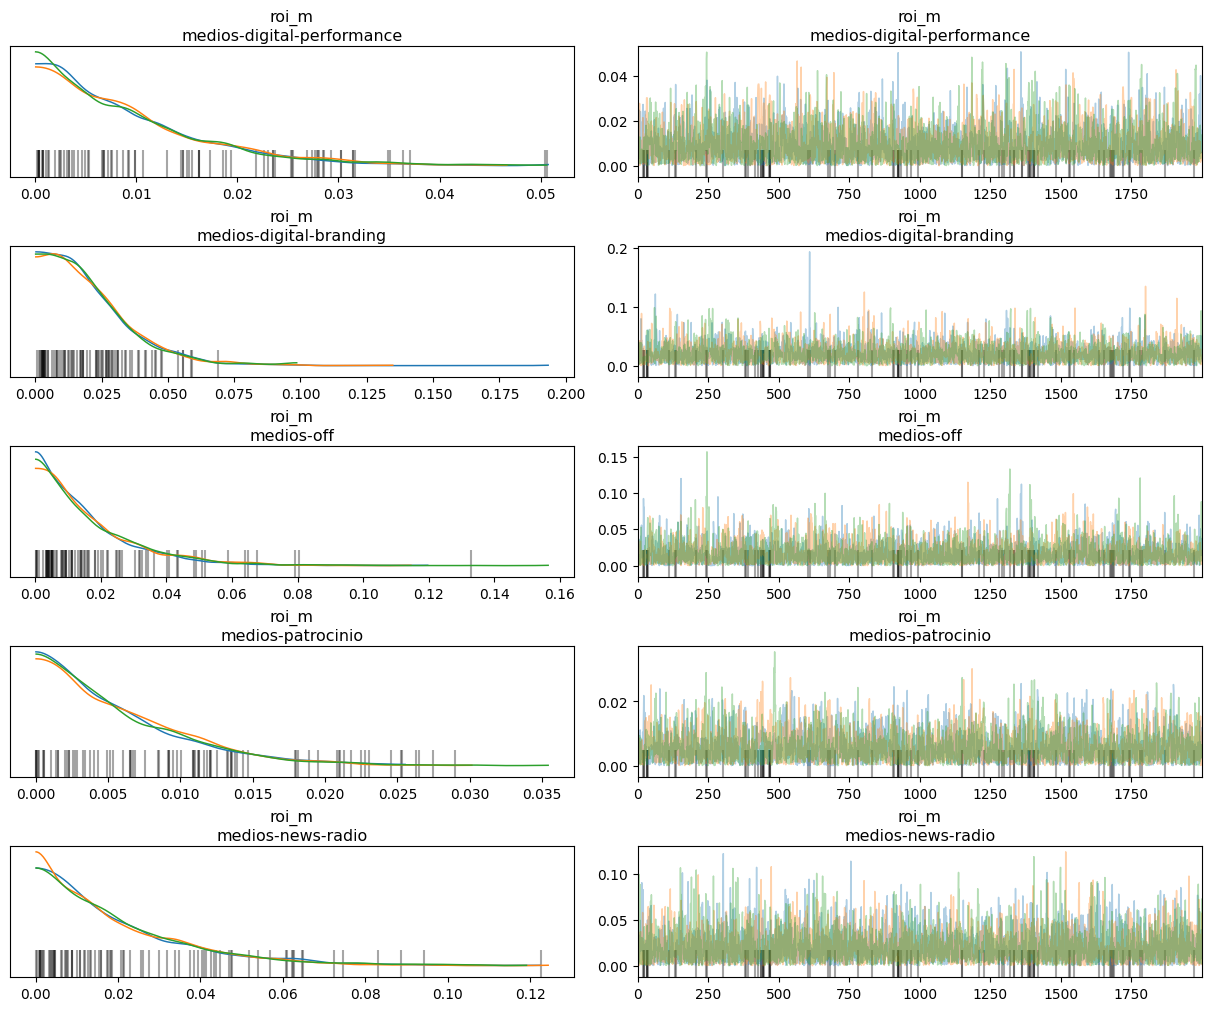

In [7]:
# ==================================================
# DIAGNÓSTICOS DE CONVERGENCIA Y DISTRIBUCIÓN POSTERIOR
# ==================================================

# Crear un objeto de diagnóstico para evaluar la calidad del muestreo MCMC.
model_diagnostics = visualizer.ModelDiagnostics(mmm)

# R-hat: métrica de convergencia del MCMC (debe ser < 1.1 para indicar convergencia adecuada).
# Visualiza un boxplot con los valores de R-hat para todos los parámetros.
fig = model_diagnostics.plot_rhat_boxplot()
fig.show()

# 🔍 Comparación visual entre la distribución a priori y a posteriori de los parámetros del modelo.
# Permite ver cómo los datos actualizaron nuestras creencias iniciales.
fig = model_diagnostics.plot_prior_and_posterior_distribution()
fig.show()

# =======================================
# CURVAS DE RESPUESTA Y DECAY DE ADSTOCK
# =======================================

# Crear análisis de efectos dinámicos
media_effects = visualizer.MediaEffects(mmm)

# 📉 Curvas de respuesta (saturación - función Hill)
fig_response_curves = media_effects.plot_response_curves()
fig_response_curves.show()

# ⏳ Curvas de adstock (decaimiento en el tiempo)
fig_adstock_decay = media_effects.plot_adstock_decay()
fig_adstock_decay.show()

# ==============================================
# VISUALIZACIÓN DE LA TRAZA Y POSTERIOR DE ROI
# ==============================================

# Lista de parámetros que quieres visualizar (puedes especificar uno o todos los canales)
parameters_to_plot = ["roi_m"]  # Esto grafica todos los canales si roi_m es vectorial

for param in parameters_to_plot:
    az.plot_trace(
        mmm.inference_data,           # Datos inferidos del modelo Meridian
        var_names=param,              # Nombre del parámetro a visualizar
        compact=False,                # Muestra una fila por parámetro (más claro)
        backend_kwargs={
            "constrained_layout": True  # Optimiza el layout de la figura
        }
    )

In [8]:
# =========================================
# REPORTE DEL MODELO
# =========================================

# Crear el objeto summarizer a partir del modelo entrenado
mmm_summarizer = summarizer.Summarizer(mmm)

# Definir ruta donde guardar el archivo
output_dir = "./summarizer/"  # o tu carpeta
output_filename = "resumen_modelo_meridian.html"

# Definir fechas del período modelado (asegúrate de usar las reales)
start_date = "2022-01-01"   # cambia por la fecha real de inicio en tu data
end_date = "2025-11-01"     # cambia por la fecha real de fin

# Exportar el archivo HTML con el resumen
mmm_summarizer.output_model_results_summary(
    output_filename,
    output_dir,
    start_date,
    end_date
)

print(f"✅ Modelo guardado en: {output_dir}/{output_filename}")

/Users/mauriciosierra/Documents/meridian-mio/meridian/analysis/analyzer.py:945: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
/Users/mauriciosierra/Documents/meridian-mio/meridian/analysis/analyzer.py:630: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(
/Users/mauriciosierra/Documents/meridian-mio/meridian/analysis/analyzer.py:630: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(
/Users/mauriciosierra/Documents/meridian-mio/.venv_meridian/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/Users/mauriciosierra/Documents/meridian-mio/meridian/analysis/analyzer.py:3239: UserWarning: Effectiveness is not reported because it does not have a clear interpretation by time

✅ Modelo guardado en: ./summarizer//resumen_modelo_meridian.html


In [9]:
# ========================================
# OPTIMIZACIÓN PRESUPUESTARIA
# ========================================

# Crear el optimizador desde el modelo entrenado
budget_optimizer = optimizer.BudgetOptimizer(mmm)
num_paid_channels = len(media_to_channel)  # Afiliacion, Meta, Google, Billing, 4 Off-line
num_canales = num_paid_channels

# 1. Definir las restricciones inferiores
# Inicialmente, todos los canales pueden bajar al 70%
lower_constraints = [0.5] * num_canales
upper_constraints = [0.5] * num_canales

# Fijar la TV (índice 5) al 100% de su gasto
lower_constraints[4] = 0

# 2. Definir las restricciones superiores
# Inicialmente, todos los canales pueden subir al 130%
upper_constraints = [0.5] * num_canales

# Ejecutar la optimización con todos los parámetros configurables
optimization_results = budget_optimizer.optimize(
    use_posterior=True,
    selected_times=None,
    fixed_budget=True, # Mantenemos el presupuesto total fijo
    budget=None, # None = usa el gasto histórico total
    start_date = start_date,
    end_date = end_date,
    # Restricciones Ajustadas
    spend_constraint_lower=lower_constraints,
    spend_constraint_upper=upper_constraints,
    target_roi=None,
    target_mroi=None,
    gtol=0.0001,
    use_optimal_frequency=True,
    use_kpi=True,
    confidence_level=0.9,
    batch_size=3000
)

# ========================================
# EXPORTAR Y SUBIR RESULTADOS
# ========================================

import os

# 1️⃣ Crear el directorio temporal local
local_dir = "./optimizer/"
os.makedirs(local_dir, exist_ok=True)

output_filename = "optimization_output.html"
local_path = os.path.join(local_dir, output_filename)

# 2️⃣ Generar el resumen de optimización en local
optimization_results.output_optimization_summary(
    filename=output_filename,
    filepath=local_dir
)

print(f"✅ Reporte de optimización guardado en: {local_path}")

✅ Reporte de optimización guardado en: ./optimizer/optimization_output.html


In [10]:
# ===========================
# AJUSTE DEL MODELO AL KPI
# ===========================

# Crear objeto para evaluar el ajuste del modelo en la muestra (in-sample).
model_fit = visualizer.ModelFit(mmm)

# 📈 Gráfico del KPI observado vs el KPI estimado por el modelo (por semana).
# Ideal para mostrar qué tan bien se ajusta el modelo a los datos reales.
fig = model_fit.plot_model_fit()
fig.show()

# ============================
# ANÁLISIS DE MEDIOS PAGADOS
# ============================

# Crear resumen de medios
media_summary = visualizer.MediaSummary(mmm)

# 💧 Waterfall chart: contribución de cada canal
fig_waterfall = media_summary.plot_contribution_waterfall_chart()
fig_waterfall.show()

# 🥧 Pie chart: proporción de contribución por canal
fig_pie = media_summary.plot_contribution_pie_chart()
fig_pie.show()

# 💸 Spend vs Contribución real
fig_spend_vs_contribution = media_summary.plot_spend_vs_contribution()
fig_spend_vs_contribution.show()

# 📊 ROI por canal
fig_roi_bar = media_summary.plot_roi_bar_chart()
fig_roi_bar.show()

# 🔁 ROI vs Efectividad
fig_roi_vs_effectiveness = media_summary.plot_roi_vs_effectiveness()
fig_roi_vs_effectiveness.show()

# 📈 ROI vs mROI
fig_roi_vs_mroi = media_summary.plot_roi_vs_mroi()
fig_roi_vs_mroi.show()

/Users/mauriciosierra/Documents/meridian-mio/meridian/analysis/analyzer.py:945: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
/Users/mauriciosierra/Documents/meridian-mio/meridian/analysis/analyzer.py:630: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(


alt.LayerChart(...)

/Users/mauriciosierra/Documents/meridian-mio/meridian/analysis/analyzer.py:945: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(


alt.LayerChart(...)

alt.LayerChart(...)

alt.FacetChart(...)

alt.LayerChart(...)

alt.Chart(...)

alt.Chart(...)

In [18]:
# Ruta donde quieres guardar el modelo (ajusta según tu entorno)
model_path = "./saved_mmm.pkl"

# Guardar el modelo entrenado como un archivo .pkl
model.save_mmm(mmm, model_path)
print(f"✅ Modelo guardado en: {model_path}")

✅ Modelo guardado en: ./saved_mmm.pkl


In [22]:
# Ruta al archivo previamente guardado
model_path = "./saved_mmm.pkl"

# Cargar el modelo desde el archivo
mmm = model.load_mmm(model_path)
print("✅ Modelo cargado correctamente desde:", model_path)

✅ Modelo cargado correctamente desde: ./saved_mmm.pkl
